# options
- do it all under the hood in jaxoplanet, trust me it's faster because it's jax under the hood...
  -  but we don't see any of the jax happening, and doing a head to head comparison might be tricky?
  -  how do we distinguish ourselves from the docs? I think showing that speed comparison...
- switch to some other science case.
    - flare pre-processing could work
- write a bad transit model in  jax

notebook is about jax, not the transit model!

the battle. have to work around these things in jax.

butcher transit model in favor of jax working.

# Transit-fitting with JAX
In our first tutorial, we learned how to set up `JAX` on TIKE and perform some basic calculations. In the second notebook, we convinced ourselves that it was indeed possible to speed up code by using `JAX`'s parallelization.

So far, we've only explored small code snippets. Let's go a step further and use JAX to do some real science.

`emcee` is a popular tool used for scientific inference. This notebook will work through how to leverage `JAX` on TIKE to efficiently infer the properties of an exoplanet's lightcurve.

As before, we'll first install `jax`.

In [1]:
!pip install -U jax

  Using cached jax-0.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.7.1-cp311-cp311-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached ml_dtypes-0.5.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
Using cached jax-0.7.1-py3-none-any.whl (2.8 MB)
Using cached jaxlib-0.7.1-cp311-cp311-manylinux_2_27_x86_64.whl (81.1 MB)
Using cached ml_dtypes-0.5.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (4.9 MB)
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [jax]2/3 [jax]ib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.3 which is incompatible.


In [2]:
!pip install numpyro

  Using cached numpyro-0.19.0-py3-none-any.whl.metadata (37 kB)
Using cached numpyro-0.19.0-py3-none-any.whl (370 kB)


In [3]:
import jax
import batman
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def generate_transit_data(n_points=200, noise_level=0.001, seed=42):
    """
    Generate synthetic transit light curve with batman.

    Inputs
    ------
        :n_points: (int) number of data points
        :noise_level: (float) relative to the normalized flux, the standard deviation of the injected Gaussian noise
        :seed: (int) random seed used to initialize the pseudo-random number generator that sets the noise instance.

    Outputs
    -------
        :time: (array) the timestamps used for the simulated lightcurve.
        :flux_obs: (array) the simulated flux observations, normalized so that the (noiseless) out-of-transit baseline is 1.
        :flux_err: (array) the uncertainty on the simulated lightcurve. These values are constant and are set entirely by the noise level.
        :true_params: (dict) the input parameters used to generate the simulated lightcurve.
        
    """
    # True transit parameters
    true_params = {
        't0': 0.0,          # Transit center time
        'per': 3.5,         # Orbital period (days) 
        'rp': 0.1,          # Planet radius (stellar radii)
        'a': 12.0,          # Semi-major axis (stellar radii)
        'inc': 87.0,        # Inclination (degrees)
        'ecc': 0.0,         # Eccentricity
        'w': 90.0,          # Longitude of periastron (degrees)
        'limb_dark': "quadratic",  # Limb darkening law
        'u': [0.3, 0.2]     # Limb darkening coefficients
    }
    
    # Set up batman parameters
    params = batman.TransitParams()
    for key, value in true_params.items():
        setattr(params, key, value)
    
    # Time array spanning transit
    time = np.linspace(-0.15, 0.15, n_points)  # 0.3 days around transit
    
    # Calculate true light curve
    m = batman.TransitModel(params, time)
    flux_true = m.light_curve(params)
    
    # Add noise that is deterministic and set by the seed.
    np.random.seed(seed)
    flux_obs = flux_true + np.random.normal(0, noise_level, n_points)
    flux_err = np.full_like(flux_obs, noise_level)
    
    return time, flux_obs, flux_err, true_params

In [5]:
def transit_model(theta, time):
    """
    Calculate transit light curve for given parameters and time

    Inputs
    -------
        :theta: (list) input parameters [t0, rp, a, inc]
        :time: (array) time stamps for which to calculate the model planetary transit.

    Outputs
    -------
        :lightcurve: (array) modeled flux observations to which the data will be compared.
    """
    t0, rp, a, inc = theta
    
    # Set up batman parameters (fixed values)
    params = batman.TransitParams()
    params.t0 = t0
    params.per = 3.5         # Fixed period, because we've only simulated one transit.
    params.rp = rp
    params.a = a
    params.inc = inc
    params.ecc = 0.0         # Fixed circular orbit
    params.w = 90.0          # Fixed
    params.limb_dark = "quadratic"
    params.u = [0.3, 0.2]    # Fixed limb darkening
    
    # Calculate model
    m = batman.TransitModel(params, time)
    lightcurve = m.light_curve(params) 
    return lightcurve

True parameters:
  t0 = 0.0000
  rp = 0.1000
  a = 12.00
  inc = 87.00°


Text(0, 0.5, 'normalized flux')

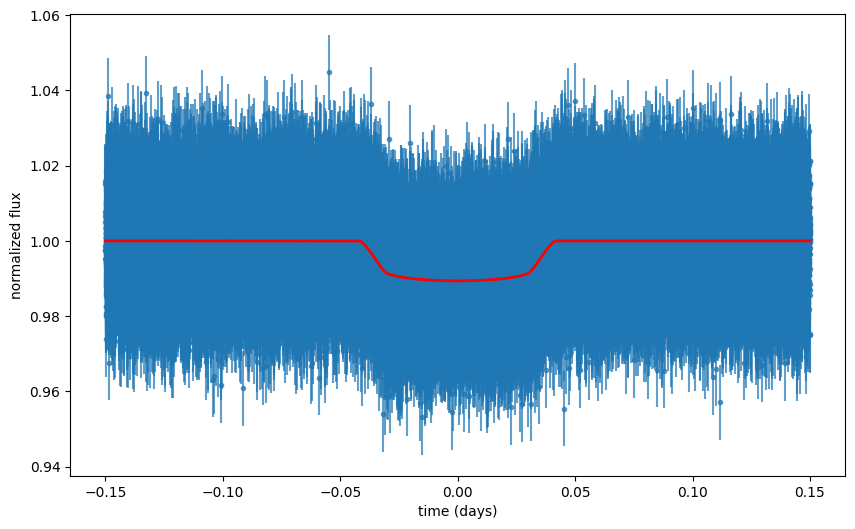

In [6]:
time, flux, flux_err, true_params = generate_transit_data(n_points=50000,noise_level=0.01)

print("True parameters:")
print(f"  t0 = {true_params['t0']:.4f}")
print(f"  rp = {true_params['rp']:.4f}")
print(f"  a = {true_params['a']:.2f}")
print(f"  inc = {true_params['inc']:.2f}°")

# Plot data
plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=flux_err, fmt='o', alpha=0.7, 
             markersize=3, label='Synthetic data')

# Plot true model
true_theta = [true_params['t0'], true_params['rp'], 
              true_params['a'], true_params['inc']]
true_model = transit_model(true_theta, time)
plt.plot(time, true_model, 'r-', linewidth=2, label='True model', zorder=100)
plt.xlabel('time (days)')
plt.ylabel('normalized flux')

Great, it looks like we were able to simulate a noisy transit observation. The "data" lie somewhat close to the true model that we generated, with some Gaussian-looking scatter (i.e., there seems to be about as many points above the model line as below, and the points are clustered toward the model line).

Next, let's set up our Bayesian inference problem. The first component that we need is a model to which we can compare our data. This will be just a simple transit model yet again, keeping some of the less important (and more degenerate!) parameters constant.1

In [7]:
def log_prob(theta, time, flux, flux_err):
    """
    Log probability function for transit fitting
    theta = [t0, rp, a, inc]
    """
    t0, rp, a, inc = theta

    t0_min, t0_max = -0.05, 0.05
    rp_min, rp_max = 0.05, 0.2
    a_min, a_max = 8.0, 20.0
    inc_min, inc_max = 80.0, 90.0
    
    # Priors
    if not (t0_min < t0 < t0_max):          # Transit time prior
        return -np.inf
    if not (rp_min < rp < rp_max):          # Planet radius prior
        return -np.inf  
    if not (a_min < a < a_max):             # Semi-major axis prior
        return -np.inf
    if not (inc_min < inc < inc_max):       # Inclination prior (nearly edge-on)
        return -np.inf

    # Likelihood
    try:
        # Calculate model light curve
        model = transit_model(theta, time)
        
        # Log likelihood (Gaussian)
        chi2 = np.sum(((flux - model) / flux_err) ** 2)
        log_likelihood = -0.5 * chi2
        
        return log_likelihood
        
    except Exception:
        # Batman can fail for unphysical parameters
        return -np.inf


In [8]:
import numpyro
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

In [33]:
def model(time, flux, flux_err):
    # Priors
    t0 = numpyro.sample("t0", dist.Uniform(-0.05, 0.05))
    rp = numpyro.sample("rp", dist.Uniform(0.05, 0.2))
    a = numpyro.sample("a", dist.Uniform(8.0, 20.0))
    inc = numpyro.sample("inc", dist.Uniform(80.0, 90.0))
    
    theta = (t0, rp, a, inc)
    
    # Transit model
    # try:
    #     model_flux = transit_model(theta, time)
    # except Exception:
    #     # For unphysical parameters, return very unlikely value
    #     # NumPyro expects arrays, so we can set a very small likelihood
    #     numpyro.factor("unphysical", -1e20)
    #     return
    model_flux = transit_model(theta, time)

    # Gaussian likelihood
    numpyro.sample("obs", dist.Normal(model_flux, flux_err), obs=flux)

In [32]:
assert np.all(np.isfinite(flux_err))
assert np.all(flux_err > 0)

In [10]:
from numpyro.infer import MCMC, NUTS
import numpyro.infer as infer
from jax.random import PRNGKey


In [18]:
jax.local_device_count() # todo: why is that?

1

In [34]:
nuts_kernel = infer.NUTS(model)
mcmc = infer.MCMC(nuts_kernel, num_warmup=1000, num_samples=4000,
                 num_chains=2,)
rng_key = PRNGKey(0)
mcmc.run(rng_key, time=time, flux=flux, flux_err=flux_err)
samples = mcmc.get_samples()

/tmp/ipykernel_896/1890432897.py:2: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = infer.MCMC(nuts_kernel, num_warmup=1000, num_samples=4000,


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[]
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError

(array([3948.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        4052.]),
 array([ 8.        ,  9.19999981, 10.39999962, 11.59999943, 12.79999924,
        13.99999905, 15.19999886, 16.39999771, 17.59999847, 18.79999924,
        19.99999809]),
 <BarContainer object of 10 artists>)

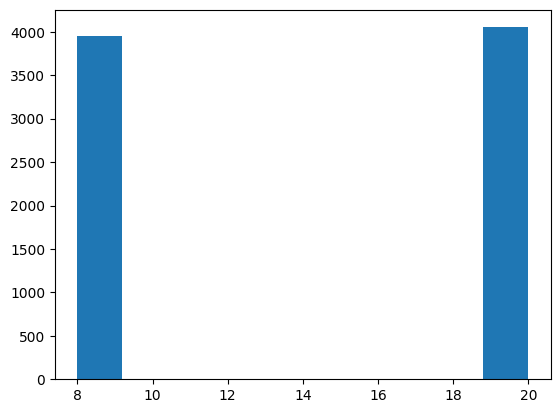

In [31]:
plt.hist(samples['a'])

In [26]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     14.08      6.00     20.00      8.00     20.00   7577.56      1.00
       inc     84.93      5.00     80.00     80.00     90.00   7577.56      1.00
        rp      0.13      0.07      0.20      0.05      0.20   7641.16      1.00
        t0     -0.00      0.05     -0.05     -0.05      0.05   7577.56      1.00

Number of divergences: 0


In [27]:
import corner


In [28]:
import arviz as az

inf_data = az.from_numpyro(mcmc)
az.summary(inf_data)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,14.078,6.000,8.00,20.00,0.069,0.049,7610.0,7610.0,1.0
inc,84.935,5.000,80.00,90.00,0.057,0.041,7610.0,7610.0,1.0
rp,0.127,0.075,0.05,0.20,0.001,0.001,7652.0,7652.0,1.0
t0,-0.001,0.050,-0.05,0.05,0.001,0.000,7610.0,7610.0,1.0


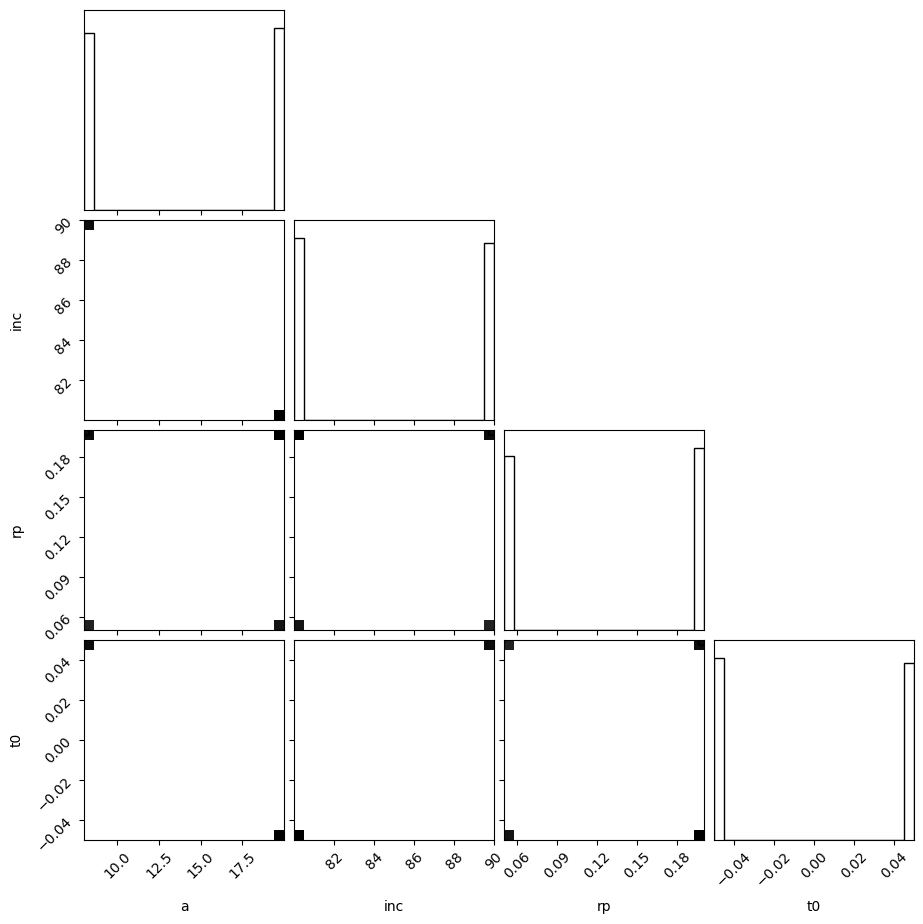

In [29]:
import corner

corner.corner(inf_data);